# 05 - Theme first derivative (catch the take-off)

Identical logic to notebook 03, but operating on **themes** instead of individual
tickers. Reads `data/processed/daily_theme_counts.parquet` (produced by notebook 04).

**The idea:** smooth the daily theme signal, then take the first derivative
(how much did it change since yesterday?). When that speed jumps well above normal,
a theme is catching fire in retail discussion. We mark those days in red.

Notebook 04 saves **two signals per theme** — pick which one to analyse with
`VALUE_COLUMN`:

- `keyword_count` — posts whose text mentions the theme's words/phrases
- `inferred_count` — ticker mentions mapped to the theme (NVDA → ai, ...)
- `keyword_weighted` / `inferred_weighted` — the upvote-weighted (score²) versions

In [1]:
import os, sys
ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
sys.path.insert(0, ROOT)
print('project root:', ROOT)

project root: c:\Users\alexd\Desktop\GIC\RetailFlow1


In [2]:
# ============ PARAMETERS - edit these ============
DAILY_THEMES_PATH = os.path.join(ROOT, 'data', 'processed', 'daily_theme_counts.parquet')
VALUE_COLUMN      = 'keyword_count'   # 'keyword_count', 'inferred_count',
                                      # 'keyword_weighted' or 'inferred_weighted'
THEMES            = []     # e.g. ['ai', 'gold_metals']; [] = use the TOP_N most mentioned
TOP_N             = 4
SMOOTH            = 3      # rolling-average window in days
K                 = 2.0    # std-devs above normal that counts as a take-off
# ==================================================

In [3]:
# ============ TIME WINDOW - edit freely ============
# Clips the daily counts before the analysis. None = keep everything in the
# counts file (which was already windowed when notebook 02/04 produced it).
START_DATE = None   # inclusive,  'YYYY-MM-DD' or None
END_DATE   = None   # EXCLUSIVE,  'YYYY-MM-DD' or None
# ====================================================

In [4]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Force-reload src.inflection so an already-running kernel picks up edits
# to the module without a restart (same reasoning as notebook 03).
import importlib
import src.inflection
importlib.reload(src.inflection)
from src.inflection import build_daily_series, compute_inflection

def format_date_axis(ax, rotate=45):
    """Weekly (Monday) YYYY-MM-DD ticks - same axis style as notebook 03."""
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_minor_locator(mdates.DayLocator())
    for label in ax.get_xticklabels():
        label.set_rotation(rotate)
        label.set_ha('right')
        label.set_fontsize(7)
    ax.grid(True, which='major', axis='x', alpha=0.3)

daily = pd.read_parquet(DAILY_THEMES_PATH)
daily['date'] = pd.to_datetime(daily['date'])

# Apply the time window from the cell above.
if START_DATE:
    daily = daily[daily['date'] >= pd.Timestamp(START_DATE)]
if END_DATE:
    daily = daily[daily['date'] < pd.Timestamp(END_DATE)]
print('window:', START_DATE, 'to', END_DATE, '|', len(daily), 'daily rows kept')

# inflection.py expects a 'ticker' column; rename 'theme' so it works unchanged.
daily = daily.rename(columns={'theme': 'ticker'})

# Old theme files had mention_count; the new ones have the four signal
# columns. Fall back sensibly either way.
if VALUE_COLUMN not in daily.columns:
    fallback = 'keyword_count' if 'keyword_count' in daily.columns else 'mention_count'
    print('NOTE:', VALUE_COLUMN, 'not found - using', fallback, 'instead.')
    VALUE_COLUMN = fallback

if THEMES:
    chosen = THEMES
else:
    totals = daily.groupby('ticker')[VALUE_COLUMN].sum().sort_values(ascending=False)
    chosen = list(totals.head(TOP_N).index)
print('analysing:', chosen, '| signal:', VALUE_COLUMN)

window: None to None | 7131 daily rows kept
analysing: ['crypto', 'meme_stocks', 'short_squeeze', 'financials'] | signal: keyword_count



crypto (keyword_count): 6 rise day(s), 3 fall day(s), 2 peak(s), 1 trough(s)
    RISE   2021-01-28 | value 2211 | velocity 539.3
    RISE   2021-01-29 | value 3139 | velocity 815.3
    RISE   2021-01-30 | value 1873 | velocity 289.3
    RISE   2021-04-14 | value 1694 | velocity 280.7
    RISE   2021-05-13 | value 2435 | velocity 232.3
    RISE   2021-05-19 | value 2731 | velocity 407.0
    FALL   2021-02-01 | value 1804 | velocity -445.0
    FALL   2021-05-16 | value 1510 | velocity -308.3
    FALL   2021-05-22 | value 1450 | velocity -427.0
    PEAK   2021-01-30
    PEAK   2021-05-21
    TROUGH 2021-03-22


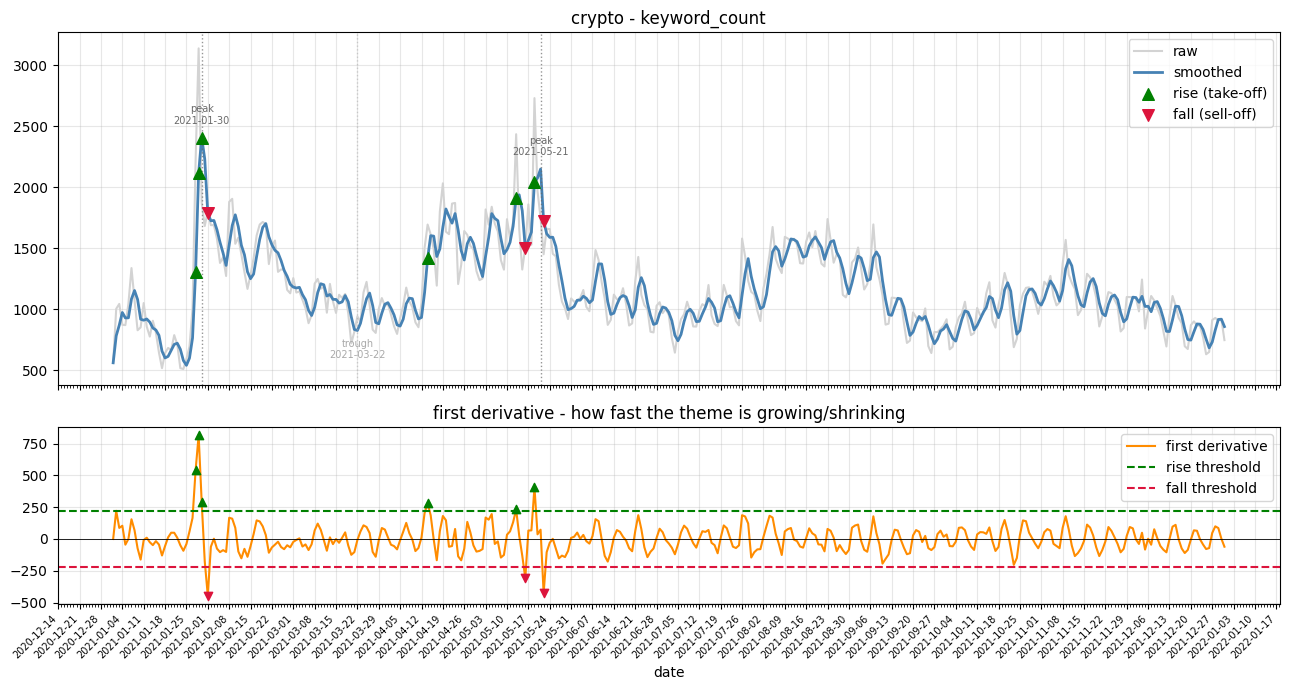


meme_stocks (keyword_count): 4 rise day(s), 7 fall day(s), 1 peak(s), 0 trough(s)
    RISE   2021-01-26 | value 3298 | velocity 888.7
    RISE   2021-01-27 | value 11198 | velocity 3553.3
    RISE   2021-01-28 | value 15872 | velocity 4526.3
    RISE   2021-01-29 | value 12150 | velocity 2950.7
    FALL   2021-01-30 | value 6816 | velocity -1460.7
    FALL   2021-01-31 | value 6074 | velocity -3266.0
    FALL   2021-02-01 | value 9157 | velocity -997.7
    FALL   2021-02-04 | value 5098 | velocity -1353.0
    FALL   2021-02-05 | value 3914 | velocity -1456.3
    FALL   2021-02-06 | value 1439 | velocity -1283.3
    FALL   2021-02-07 | value 1017 | velocity -1360.3
    PEAK   2021-01-29


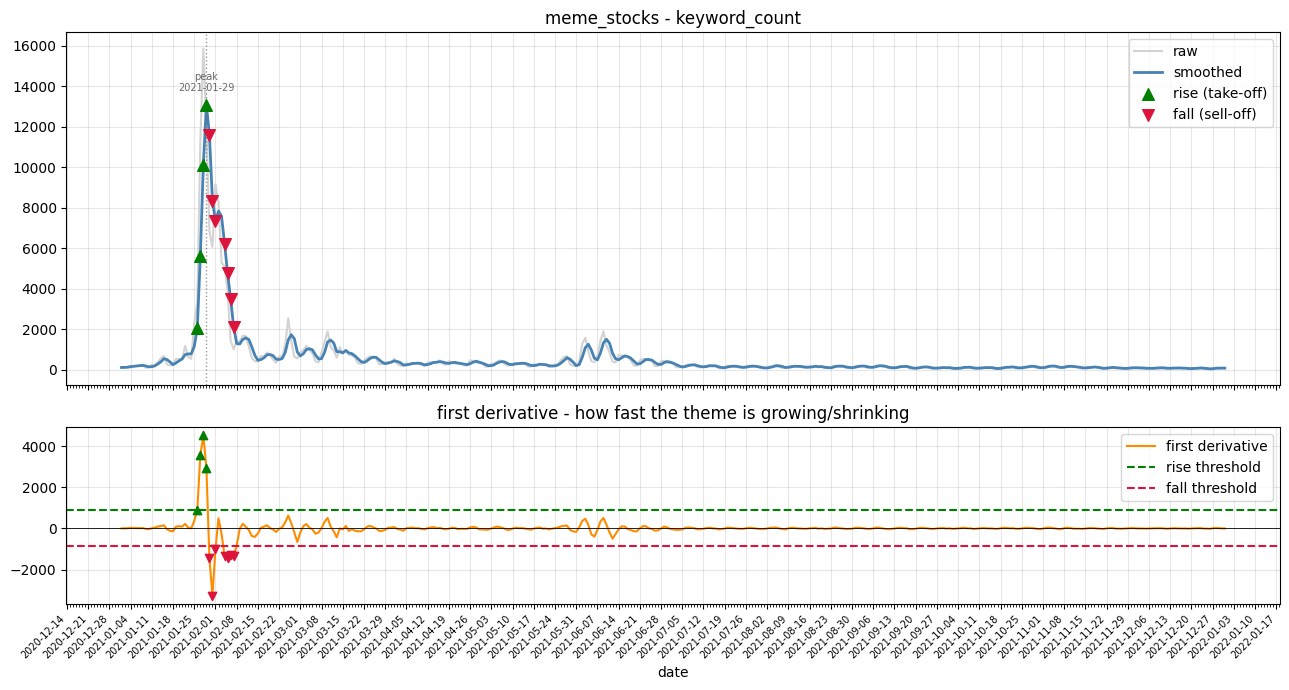


short_squeeze (keyword_count): 4 rise day(s), 7 fall day(s), 1 peak(s), 0 trough(s)
    RISE   2021-01-26 | value 958 | velocity 243.3
    RISE   2021-01-27 | value 3154 | velocity 984.3
    RISE   2021-01-28 | value 3902 | velocity 1080.7
    RISE   2021-01-29 | value 3151 | velocity 731.0
    FALL   2021-01-30 | value 2080 | velocity -358.0
    FALL   2021-01-31 | value 1898 | velocity -668.0
    FALL   2021-02-04 | value 1331 | velocity -452.3
    FALL   2021-02-05 | value 1121 | velocity -399.3
    FALL   2021-02-06 | value 383 | velocity -343.7
    FALL   2021-02-07 | value 269 | velocity -354.0
    FALL   2021-02-08 | value 345 | velocity -258.7
    PEAK   2021-01-29


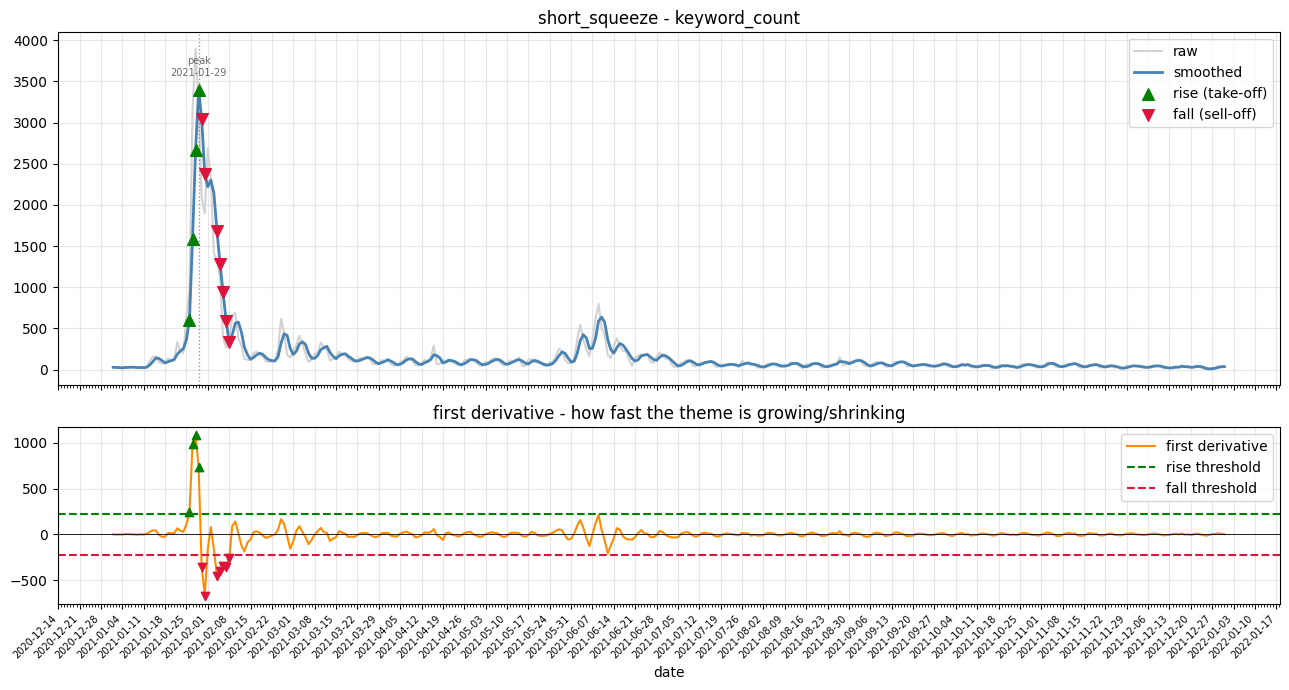


financials (keyword_count): 3 rise day(s), 3 fall day(s), 1 peak(s), 0 trough(s)
    RISE   2021-01-27 | value 406 | velocity 98.7
    RISE   2021-01-28 | value 747 | velocity 194.7
    RISE   2021-01-29 | value 520 | velocity 116.3
    FALL   2021-01-31 | value 300 | velocity -149.0
    FALL   2021-02-05 | value 223 | velocity -51.7
    FALL   2021-02-07 | value 151 | velocity -60.3
    PEAK   2021-01-29


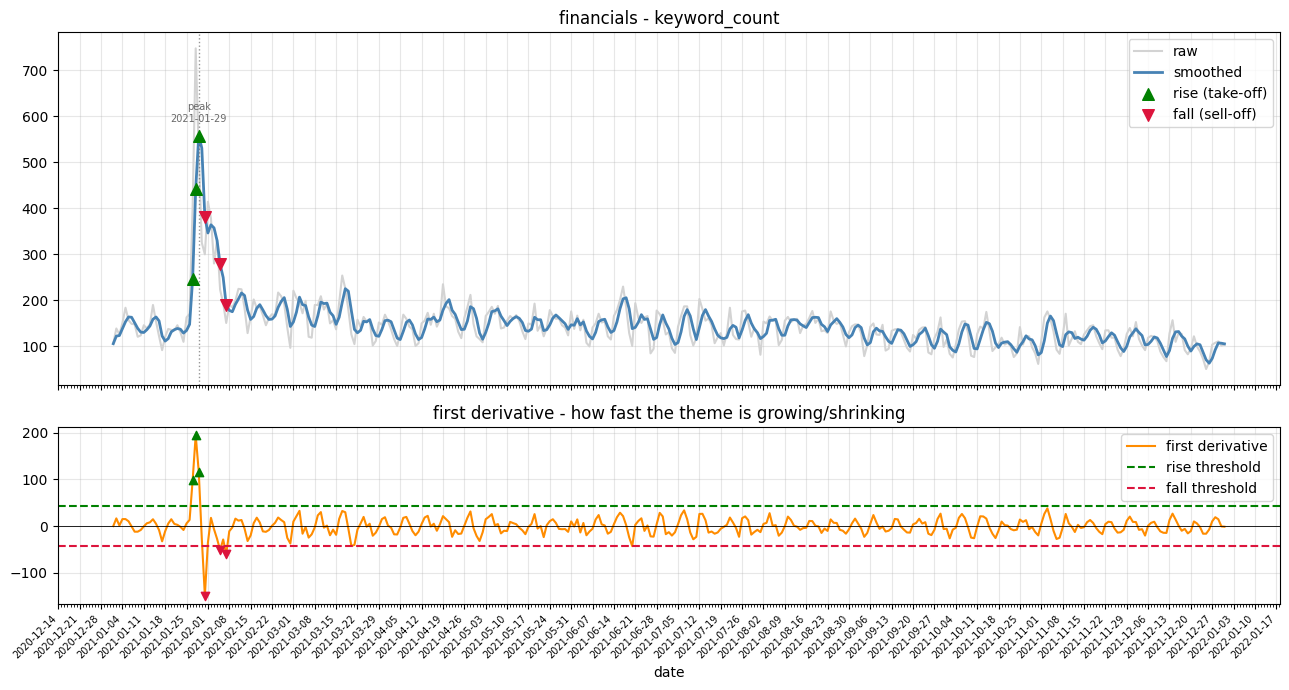

In [5]:
for theme in chosen:
    series = build_daily_series(daily, theme, value_col=VALUE_COLUMN)
    if series is None:
        print('skip', theme, '(not found)'); continue
    result = compute_inflection(series, SMOOTH, K)
    rises = result[result['is_rise']]
    falls = result[result['is_fall']]
    peaks = result[result['is_peak']]
    troughs = result[result['is_trough']]

    print(f'\n{theme} ({VALUE_COLUMN}): {len(rises)} rise day(s), {len(falls)} fall day(s), '
          f'{len(peaks)} peak(s), {len(troughs)} trough(s)')
    for date, row in rises.iterrows():
        print('    RISE  ', date.strftime('%Y-%m-%d'), '| value', int(row['count']), '| velocity', round(row['velocity'], 1))
    for date, row in falls.iterrows():
        print('    FALL  ', date.strftime('%Y-%m-%d'), '| value', int(row['count']), '| velocity', round(row['velocity'], 1))
    for date in peaks.index:
        print('    PEAK  ', date.strftime('%Y-%m-%d'))
    for date in troughs.index:
        print('    TROUGH', date.strftime('%Y-%m-%d'))

    fig, (top, bottom) = plt.subplots(2, 1, figsize=(13, 7), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
    top.plot(result.index, result['count'], color='lightgray', label='raw')
    top.plot(result.index, result['smoothed'], color='steelblue', linewidth=2, label='smoothed')
    top.scatter(rises.index, rises['smoothed'], color='green', marker='^', s=70, zorder=5, label='rise (take-off)')
    top.scatter(falls.index, falls['smoothed'], color='crimson', marker='v', s=70, zorder=5, label='fall (sell-off)')
    # Peaks/troughs = where the trend itself turns; each label carries its
    # EXACT date so no squinting at the axis.
    for date in peaks.index:
        top.axvline(date, color='dimgray', linestyle=':', linewidth=1, alpha=0.7)
        top.annotate(f"peak\n{date:%Y-%m-%d}", (date, result.loc[date, 'smoothed']),
                     textcoords='offset points', xytext=(0, 10), ha='center',
                     fontsize=7, color='dimgray')
    for date in troughs.index:
        top.axvline(date, color='darkgray', linestyle=':', linewidth=1, alpha=0.5)
        top.annotate(f"trough\n{date:%Y-%m-%d}", (date, result.loc[date, 'smoothed']),
                     textcoords='offset points', xytext=(0, -20), ha='center',
                     fontsize=7, color='darkgray')
    top.set_title(f'{theme} - {VALUE_COLUMN}')
    top.legend(); top.grid(True, alpha=0.3)
    top.tick_params(labelbottom=False)   # dates appear once, on the shared axis below

    bottom.plot(result.index, result['velocity'], color='darkorange', label='first derivative')
    bottom.axhline(result.attrs['threshold'], color='green', linestyle='--', label='rise threshold')
    bottom.axhline(result.attrs['fall_threshold'], color='crimson', linestyle='--', label='fall threshold')
    bottom.axhline(0, color='black', linewidth=0.6)
    bottom.scatter(rises.index, rises['velocity'], color='green', marker='^', zorder=5)
    bottom.scatter(falls.index, falls['velocity'], color='crimson', marker='v', zorder=5)
    bottom.set_title('first derivative - how fast the theme is growing/shrinking')
    bottom.set_xlabel('date')
    bottom.legend(); bottom.grid(True, alpha=0.3)
    format_date_axis(bottom)   # weekly YYYY-MM-DD ticks, same as notebook 03
    plt.tight_layout(); plt.show()